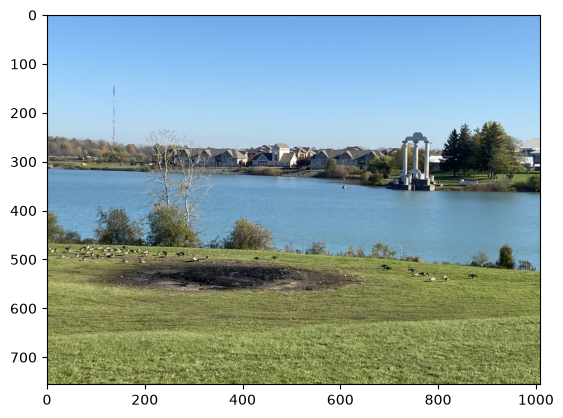

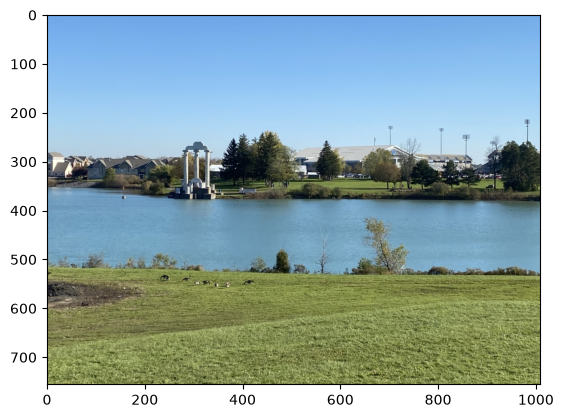

In [6]:
%matplotlib inline
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

cv2.setRNGSeed(42)
IMAGE_DIR = Path("COMP9517_26T3_Lab2_Images")
PERSONAL_PATHS = (IMAGE_DIR / "p1.jpg", IMAGE_DIR / "p2.jpg")

def read_image(path, max_width=None):
    image = cv2.imread(str(path))
    if max_width and image.shape[1] > max_width:
        scale = max_width / image.shape[1]
        image = cv2.resize(
            image, (max_width, round(image.shape[0] * scale)),
            interpolation=cv2.INTER_AREA,
        )
    return image

def show(image):
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.show()

def sift_keypoints(image, nfeatures=0):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.SIFT_create(nfeatures=nfeatures).detect(gray)

def draw_kp(image, keypoints):
    return cv2.drawKeypoints(
        image, keypoints, None, color=(0, 255, 0),
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
    )

images = [read_image(IMAGE_DIR / name) for name in ("Image1.jpg", "Image2.jpg")]
for im in images:
    show(im)

use nfeatures 20 for only 20 strongest keypoint

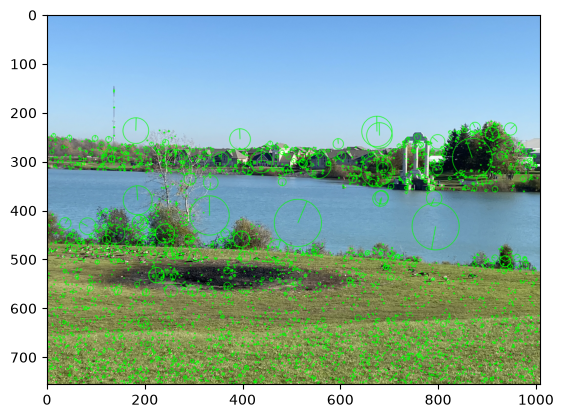

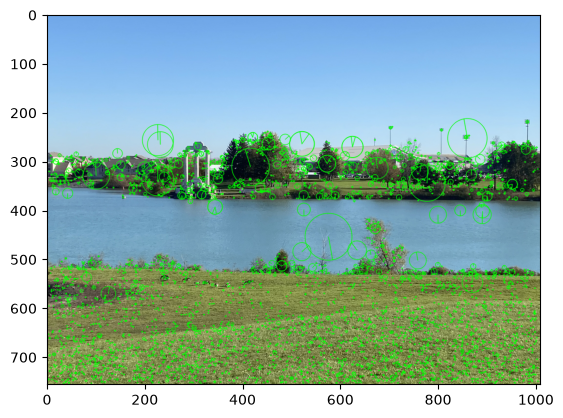

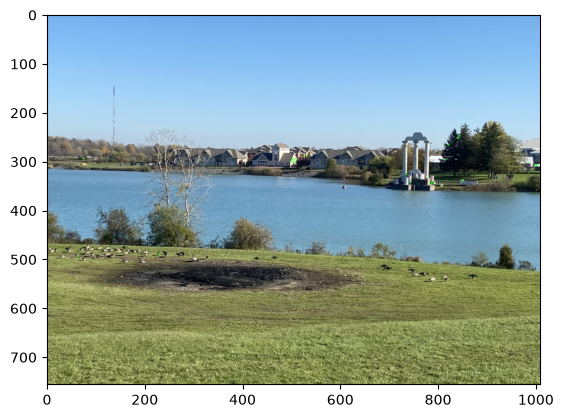

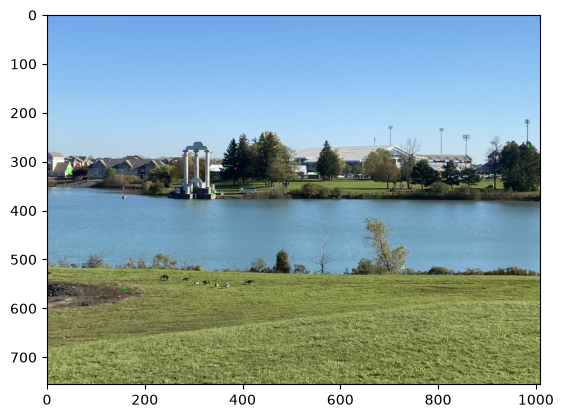

In [7]:
default_kp = [sift_keypoints(im) for im in images]
reduced_kp = [sift_keypoints(im, nfeatures=20) for im in images]

for im, kp in zip(images, default_kp):
    show(draw_kp(im, kp))

for im, kp in zip(images, reduced_kp):
    show(draw_kp(im, kp))

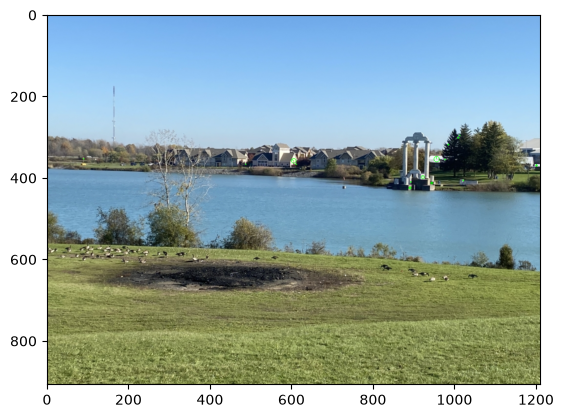

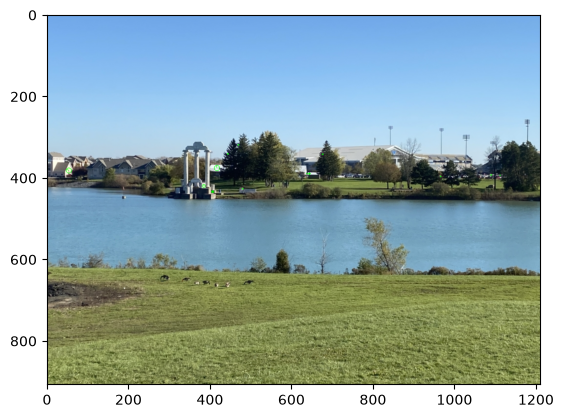

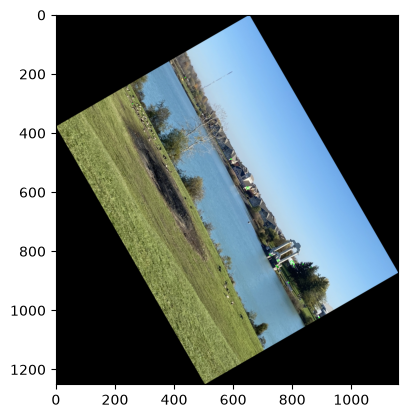

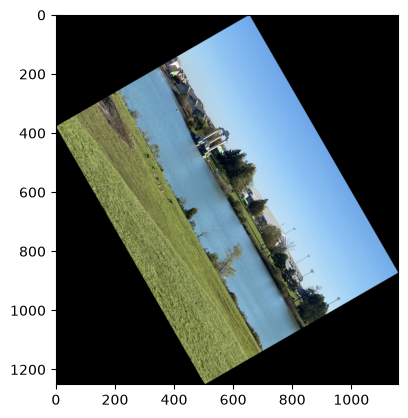

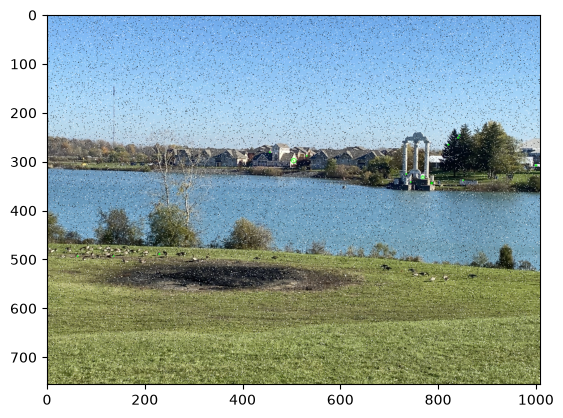

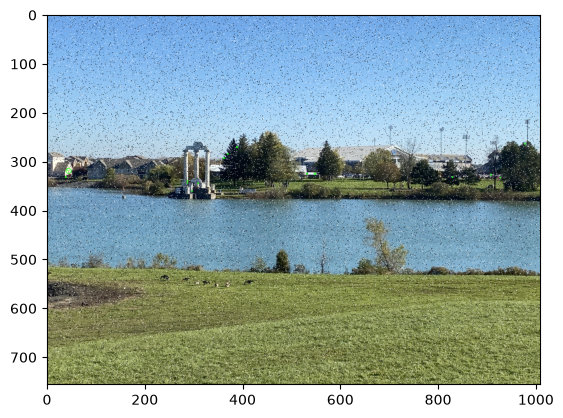

In [8]:
def rotate_clockwise(image, degrees=60):
    h, w = image.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), -degrees, 1)
    c, s = abs(M[0, 0]), abs(M[0, 1])
    nw, nh = int(np.ceil(w * c + h * s)), int(np.ceil(h * c + w * s))
    M[0, 2] += nw / 2 - w / 2
    M[1, 2] += nh / 2 - h / 2
    return cv2.warpAffine(image, M, (nw, nh))

def salt_pepper(image, amount=0.05, seed=9517):
    rng = np.random.default_rng(seed)
    out = image.copy()
    r = rng.random(image.shape[:2])
    out[r < amount / 2] = 0
    out[(r >= amount / 2) & (r < amount)] = 255
    return out

processed = [
    [cv2.resize(im, None, fx=1.2, fy=1.2) for im in images],
    [rotate_clockwise(im) for im in images],
    [salt_pepper(im, seed=9517 + i) for i, im in enumerate(images)],
]

for pair in processed:
    for im in pair:
        show(draw_kp(im, sift_keypoints(im, nfeatures=20)))

yes, roughly same for those of originals i believe

salt and pepper noise changes local contrast, so some keypoints move or disappear and new ones appear

sift works best for scale and rotation, not that good for salt and papper noise

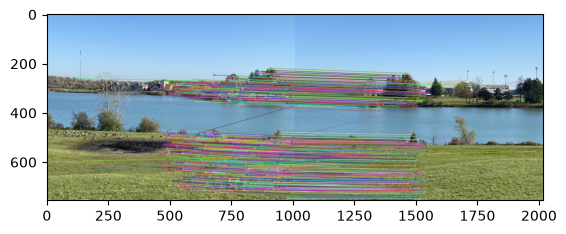

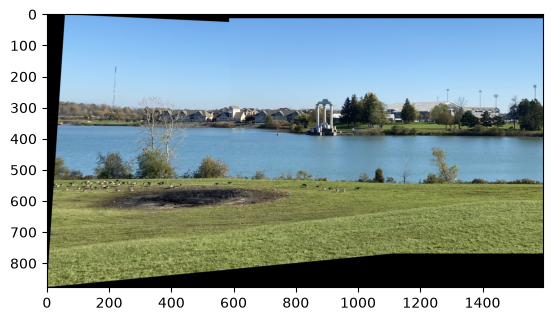

array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       ...,

       [[ 48,  84,  81],
        [ 98, 162, 156],
        [115, 179, 173],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[ 74, 111, 108],
        [112, 168, 163],
        [ 97, 148, 143],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[ 11,  17,  16],
        [  7,  10,  10],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]]

In [9]:
def stitch_pair(first, second):
    sift = cv2.SIFT_create()
    k1, d1 = sift.detectAndCompute(cv2.cvtColor(first, cv2.COLOR_BGR2GRAY), None)
    k2, d2 = sift.detectAndCompute(cv2.cvtColor(second, cv2.COLOR_BGR2GRAY), None)

    pairs = cv2.BFMatcher(cv2.NORM_L2).knnMatch(d1, d2, k=2)
    good = [m for m, n in pairs if m.distance < 0.75 * n.distance]

    # Task 3a: selected correspondences
    show(cv2.drawMatches(
        first, k1, second, k2, good, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    ))

    # Task 3b: RANSAC homography and stitch
    src = np.float32([k1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst = np.float32([k2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, _ = cv2.findHomography(src, dst, cv2.RANSAC, 4.0)

    h1, w1 = first.shape[:2]
    h2, w2 = second.shape[:2]
    corners = np.float32([[0, 0], [w1, 0], [w1, h1], [0, h1]]).reshape(-1, 1, 2)
    warped = cv2.perspectiveTransform(corners, H).reshape(-1, 2)
    both = np.vstack([warped, [[0, 0], [w2, 0], [w2, h2], [0, h2]]])
    xmin, ymin = np.floor(both.min(axis=0)).astype(int)
    xmax, ymax = np.ceil(both.max(axis=0)).astype(int)
    T = np.array([[1, 0, -xmin], [0, 1, -ymin], [0, 0, 1]], dtype=float)
    size = (int(xmax - xmin), int(ymax - ymin))

    a = cv2.warpPerspective(first, T @ H, size)
    b = cv2.warpPerspective(second, T, size)
    panorama = np.where(b > 0, b, a)

    # Crop empty border.
    gray = cv2.cvtColor(panorama, cv2.COLOR_BGR2GRAY)
    ys, xs = np.where(gray > 0)
    panorama = panorama[ys.min():ys.max() + 1, xs.min():xs.max() + 1]
    show(panorama)
    return panorama

stitch_pair(*images)

### Personal image pair

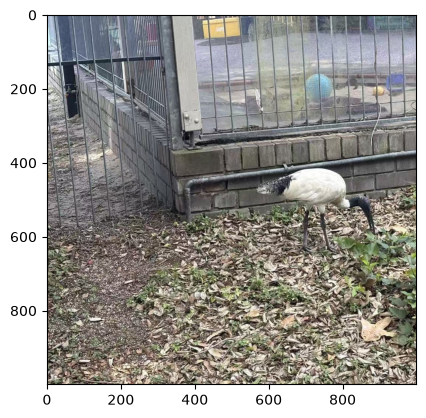

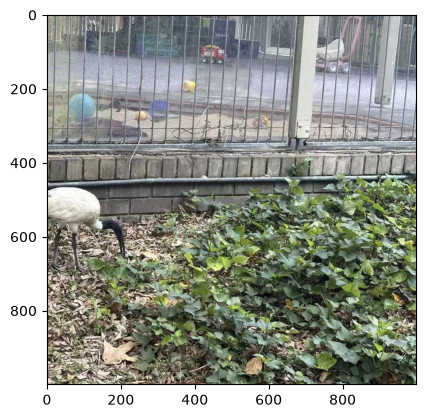

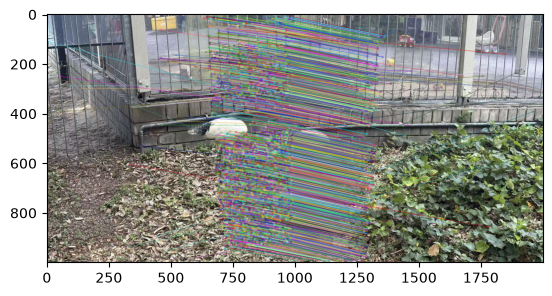

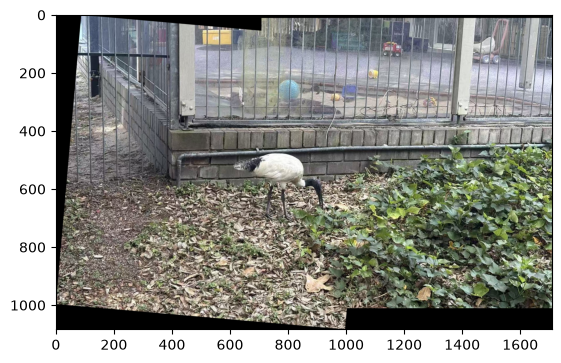

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(1084, 1709, 3), dtype=uint8)

In [10]:
personal = [read_image(p, max_width=1000) for p in PERSONAL_PATHS]
for im in personal:
    show(im)
stitch_pair(*personal)